# **Capstone project: Providing data-driven suggestions for HR**

## Section 1. Introuction





This project, part of the Google Advanced Data Analytics course, focuses on analyzing employee attrition at Salifort Motors. The goal is to identify key factors contributing to employee resignations and develop predictive models to help the company retain its workforce. The project involves data cleaning, exploratory data analysis, feature engineering, and model building using logistic regression, random forest, and XGBoost. The results are evaluated using various performance metrics, and the best model is identified for deployment.

### Business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They have refered to data analytics professionals and ask them to provide data-driven suggestions based on their understanding of the data. They have the following question: **what’s likely to make an employee leave the company?**


**Key stakeholders**

Key stakeholders for this project are the Salifort Leadership Team, HR Team and the Data Analyst Team

**Key Objective**

The primary objective of this analysis is to develop a predictive model for employee attrition using HR data. Given that high turnover significantly impacts Salifort's bottom line—particularly through the costs of recruitment and talent development—this project aims to identify the key drivers of departure. By leveraging these insights, we can implement targeted retention strategies that enhance job satisfaction and mitigate the high costs and operational disruptions associated with recruitment and onboarding.

**Relevant resources utilized**

This project uses Coursera Course Materials and Labs, Python and Python Documentation. Gemini Code Assist and Visual Studio Code (VS Code) IntelliSense

**Ethical considerations**

The dataset appears to be free of Personally Identifiable Information (PII), and the scope of this analysis is strictly limited to aggregate trends rather than individual-level data. However, several ethical and procedural points require confirmation from the data owners:

* Was the anonymity and privacy of the data subjects maintained throughout the collection process?
* Was informed consent obtained from all participants prior to the survey?
* Did employees explicitly consent to their data being used for predictive modeling to inform corporate policy, and what degree of agency did they have over its use?"

### Data Source, Description and Limitations

*Results from the HR survey contain 15,000 rows and 10 columns for the variables listed below. This data has already been downloaded and provided (HR_capstone_dataset.csv) . For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).*

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

**Data Limitations:**

1. The current dataset lacks several key variables that could provide a more comprehensive view of employee turnover:

    * **Demographics**: Age, gender, and parental status (to identify at-risk groups).
    * **Upward feedback**:  Score where employees rate their manager's performance
    * **Total Rewards**: Historical bonus data and benefit package comparisons.
    * **Market Benchmarks**: Market salary parity by role and department.
    * **Geographic Context**: Employee location to account for regional market conditions.
    * **Exit Insights**: Data on external counter-offers provided during exit interviews.
    * **Temporal and Seasonal Features**: Temporal variables, such as the month of departure, to account for seasonality (this is critical for identifying recurring trends, such as elevated attrition rates often observed in the months immediately following annual bonus distributions or performance review cycles). 
    * **Other Temporal Variables**: Specific year(s) of data collection,to determine if the timeframe includes any anomaly years—such as the 2020-2021 pandemic period—as these global events could introduce atypical attrition patterns that may not represent standard market conditions

2. The absence of critical variables introduces a risk of omitted variable bias, which can lead to skewed results or the misrepresentation of specific employee cohorts. Specifically, the lack of demographic data makes it impossible to verify the representativeness of the sample regarding gender parity or age distribution, potentially limiting the model's generalizability.

3. The absence of temporal and seasonal features limits the granularity of the data, hindering our ability to perform longitudinal analyses or isolate specific seasonal drivers of attrition.

### Import Packages and Load Data

The following section imports the necessary libraries and modules required for the analysis.

In [316]:
# Import packages


# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import plotly.express as px


# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Packages for statistics
import statsmodels.api as sm
from scipy import stats

# Import packages for data modeling

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor
# This is the function that helps plot feature importance
from xgboost import plot_importance
from sklearn.tree import plot_tree

# # This module lets us save our models once we fit them.
import pickle
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

### Load dataset

The following code loads the data, by reading the csv file, and displays the first 5 rows


In [317]:
# Load dataset into a dataframe
df_raw = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df_raw.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Section 2. Data Cleaning and Exploratory Data Analysis

This section encompasses a thorough exploratory data analysis (EDA) and data cleaning phase. We begin by standardizing column names and correcting misspellings for consistency. The dataset is then checked for missing values and duplicate records, with duplicates being removed to ensure data quality. We also perform outlier detection on the 'tenure' variable using boxplots. The EDA continues with a series of visualizations, including histograms to understand the distribution of variables for employees who left versus those who stayed, and boxplots to compare key metrics across these two groups. Furthermore, we analyze feature trends over time using line charts and explore relationships between satisfaction, evaluation, and workload using scatterplots. This multi-faceted approach helps identify the primary drivers of employee attrition, such as burnout and lack of career advancement, before proceeding to model development

**Basic Information**

The code below gathers information about the dataset, such as the number of rows and columns, data types of each column, and the presence of any missing values. This is crucial for understanding the structure of the data and identifying any potential issues that may need to be addressed during data cleaning and preprocessing.

In [318]:
# Gather basic information about the data
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


There are a total of 14999 rows and 10 columns. We have a mixture of numeric (int64 or float64) and categorical variables. We also have no missing values, which is good news.

### Data Cleaning

The code below cleans the data by as we prepare for Exoloratory Data Analysis (EDA). This includes removing duplicates, handling missing values, and renaming columns for better readability.

**Rename columns**

The code below renames the columns to be more readable and easier to work with. It also fixes misspellings and shorten names where appropriate

In [319]:
# Rename columns as needed
df_raw.rename(columns={"last_evaluation":"latest_evaluation_score",
                    "Work_accident":"work_accident", 
                    "number_project":"projects_contributed",
                    "Department":"department",
                    "time_spend_company":"tenure",
                   "average_montly_hours":"average_monthly_hours",
                   "promotion_last_5years":"promoted_in_last_5_years"
                   },
           inplace=True)
# Display all column names after the update
df_raw.columns

Index(['satisfaction_level', 'latest_evaluation_score', 'projects_contributed',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promoted_in_last_5_years', 'department', 'salary'],
      dtype='object')

**Confirming no missing values are present**

The code below confirms that there are no missing values in the data.

In [320]:
# Check for missing values
df_raw.isna().sum()

satisfaction_level          0
latest_evaluation_score     0
projects_contributed        0
average_monthly_hours       0
tenure                      0
work_accident               0
left                        0
promoted_in_last_5_years    0
department                  0
salary                      0
dtype: int64

None of the columns have any missing values

**Checking for duplicates**

The code below checks for any duplicates in the data

In [321]:
# Check for duplicates

print(f"There are a total of {df_raw.duplicated().sum()} duplicate rows in the dataset.")

There are a total of 3008 duplicate rows in the dataset.


The code below displays some of the rows with duplicate values

In [322]:
# Inspect some rows containing duplicates as needed

# Checking the first 1500 rows for duplicates and sorting by satisfaction level to make it easier to visualize
df_raw.iloc[:1500,][df_raw.iloc[:1500,].duplicated(keep=False)].sort_values("satisfaction_level")

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
178,0.37,0.51,2,127,3,0,1,0,sales,medium
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
28,0.41,0.46,2,128,3,0,1,0,accounting,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1292,0.41,0.52,2,132,3,0,1,0,RandD,low
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
9,0.42,0.53,2,142,3,0,1,0,sales,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
23,0.46,0.57,2,139,3,0,1,0,sales,low
396,0.46,0.57,2,139,3,0,1,0,sales,low


In [323]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df_raw.drop_duplicates()
# Display shape of the dataframe after dropping duplicates
df.shape

(11991, 10)

**Checking for Outliers**

The following code computes the mean, median, for our numerical, non-binary features. This summary allows us to inspect the data range and variance to identify potential outliers or anomalies that may require further investigation.

In [324]:
# Get descriptive statistics about the data
df_raw[["satisfaction_level", "latest_evaluation_score", "projects_contributed", 
        "average_monthly_hours", "tenure"]].describe().loc[["mean","50%","min","25%","75%","max"],:]

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure
mean,0.612834,0.716102,3.803054,201.050337,3.498233
50%,0.640000,0.720000,4.000000,200.000000,3.000000
min,0.090000,0.360000,2.000000,96.000000,2.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000


There is a noticeable discrepancy between the mean and the median of `tenure`. We observe a substantial gap between the 75th percentile and the maximum value for this variable. Specifically, while the interquartile range (25th to 75th percentile) shows only a 1-point increase, there is a significant 6-point jump from the 75th percentile to the maximum. 

These observations strongly suggest the presence of high-value outliers in the `tenure` variable. The code below creates a boxplot to visualize and confirm this

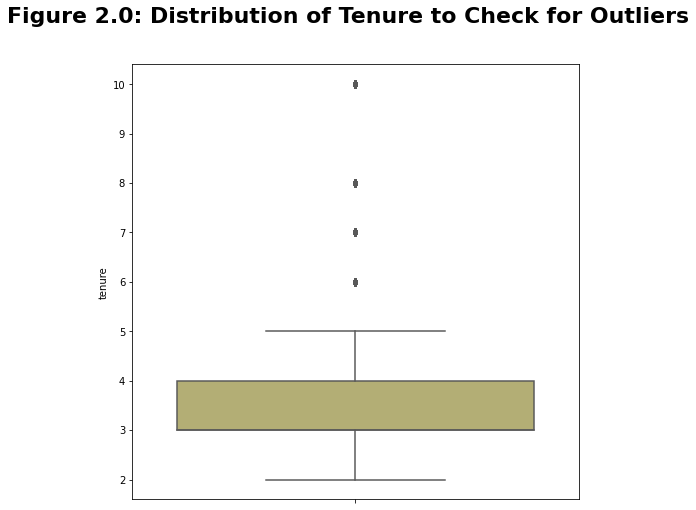

In [325]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers

fig, axes = plt.subplots(figsize=(8,8))
sns.boxplot(y=df["tenure"],color='darkkhaki')
fig.suptitle("Figure 2.0: Distribution of Tenure to Check for Outliers", fontsize=22, fontweight='bold')
plt.show()

We can see that the `tenure` variable has a couple of outliers, with the maximum tenure being 10 years. We can check for frequency of tenure values to see how many of them are outliers. 
We will define outliers as any tenure value that is greater than 1.5 times the interquartile range (IQR) for this variable.

The code below checks for the number of such values; we will only check for values greater than the upper bound since we donot see any outliers on the lower end of the boxplot

In [326]:
# Determine the number of rows containing outliers
# Any observations that are more than 1.5 IQR below Q1 or more than 1.5 IQR above Q3 are considered outliers.

# Calculate 25th percentile of tenure
percentile25 = df['tenure'].quantile(0.25)
# Calculate 75th percentile of tenure
percentile75 = df['tenure'].quantile(0.75)
# Calculate IQR
iqr = percentile75 - percentile25
# Calculate upper limit  for outliers (From the boxplot above we see that we only have outliers above the IQR for tenure)
upper_limit = percentile75 + 1.5 * iqr
outlier_rows = df[df["tenure"] > upper_limit].shape[0]

print("{} rows are outliers as they have a tenure higher than {} years".format(outlier_rows,upper_limit))
print("This is {}% of the total number of rows in the dataset".format(round(outlier_rows/df.shape[0]*100,2)))

824 rows are outliers as they have a tenure higher than 5.5 years
This is 6.87% of the total number of rows in the dataset


Since only 6.87% of total rows are outliers, we will keep them in the dataset for analysis as they may provide useful information about employees with very high tenure. 
However, we will revisit this decision after we have done some more analysis on the dataset to see if these outliers need to be accounted for in our modeling.

 ### Exploratory Data Analysis and Data Visualization

This section conducts an Exploratory Data Analysis (EDA) and creates visualizations on the cleaned dataset to examine variable distributions and their interrelationships. This analysis serves as the empirical foundation for our modeling phase, guiding necessary data transformations and deepening our insight into the key drivers of employee attrition.

**Descriptive Statistics**

We will begin by gathering descriptive statistics for all columns in our now cleaned dataset, including measures of central tendency and dispersion for numerical columns, as well as counts and unique values for categorical columns.

In [327]:
# Gather descriptive statistics about the data
df.describe(include='all')

,satisfaction_level,latest_evaluation_score,projects_contributed,average_monthly_hours,tenure,work_accident,left,promoted_in_last_5_years,department,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991,11991
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3239,5740
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,NaN,NaN
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN



* The average satisfaction score is 0.63, with a minimum of 0.09 and a maximum of 1.00. 
* The average evaluation score is 0.72, with a minimum of 0.36 and a maximum of 1.00. 
* The median number of projects contributed to is 4, with a minimum of 2 and a maximum of 7.
* All employees worked a minimum of 96 hours per month and a maximum of  <span style="color:red">**310%** </span> hours per month. The average monthly hours worked is 200.
    * This is quite surprisingly **high** given the industry average of 171 (42.8 * 4) for USA. Source: [BLS.gov](https://www.bls.gov/iag/tgs/iagauto.htm#:~:text=Table_title:%20Average%20Weekly%20Hours%20%2D%2D%20Not%20Seasonally,2025:%2042.8%20%7C%2012%2Dmonth%20changes::%20(p))
* The average tenure of employees is **3.36** years, with a minimum of 2 years and a maximum of 10 years. 
* 14.5% of employees had a work accident, while 85.5% did not have a work accident.
* Around <span style="color:darkorange">**16.6%** </span> of employees left/resigned
* 2.1% of employees were promoted in the last 5 years, while **97.9%** were not promoted.
* The most common department is sales
* The most frequent salary level is low.

#### Variable Distributions


Next we will visualize how many employees left and what percentage of all employees this figure represents.

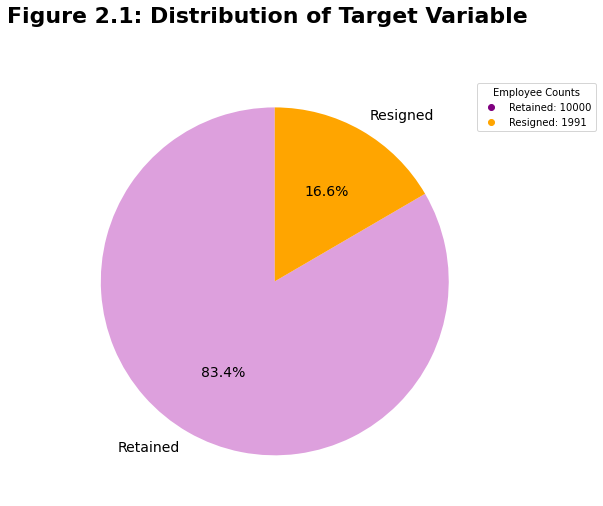

In [328]:
#plot a piechart to visualize the distribution of the target variable `left`
fig, axes = plt.subplots(figsize=(8,8))

labels = ["Retained", "Resigned"]
counts= df["left"].value_counts()
axes.pie(counts, labels=labels, autopct='%1.1f%%', colors=['plum', 'orange'], startangle=90,textprops={'fontsize': 14})

#add legend with counts
legend_labels = [f"{label}: {count}" for label, count in zip(labels, counts)]
legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='None') for color in ['purple', 'orange']]
plt.legend(legend_handles, legend_labels, title="Employee Counts",loc="center right", bbox_to_anchor=(1.25, 0.9))

fig.suptitle("Figure 2.1: Distribution of Target Variable",fontsize=22,fontweight='bold')
plt.show()

The dataset shows that 83.4% of employees stayed while 16.6% left. While this imbalance in the target variable must be accounted for during modeling, it is not severe enough to necessitate any class rebalancing.

This helps us decide which metric is best to evaluate our model. Since the dataset is imbalanced, accuracy is not a good metric to evaluate our model. 
We will utilize the F1 score as our primary metric, as its harmonic mean effectively balances the trade-off between precision and recall.

Next, we will generate histograms for all features—excluding the `left` variable—to examine their underlying distributions. These plots will be segmented by resignation status to highlight key differences and patterns between employees who stayed and those who departed.



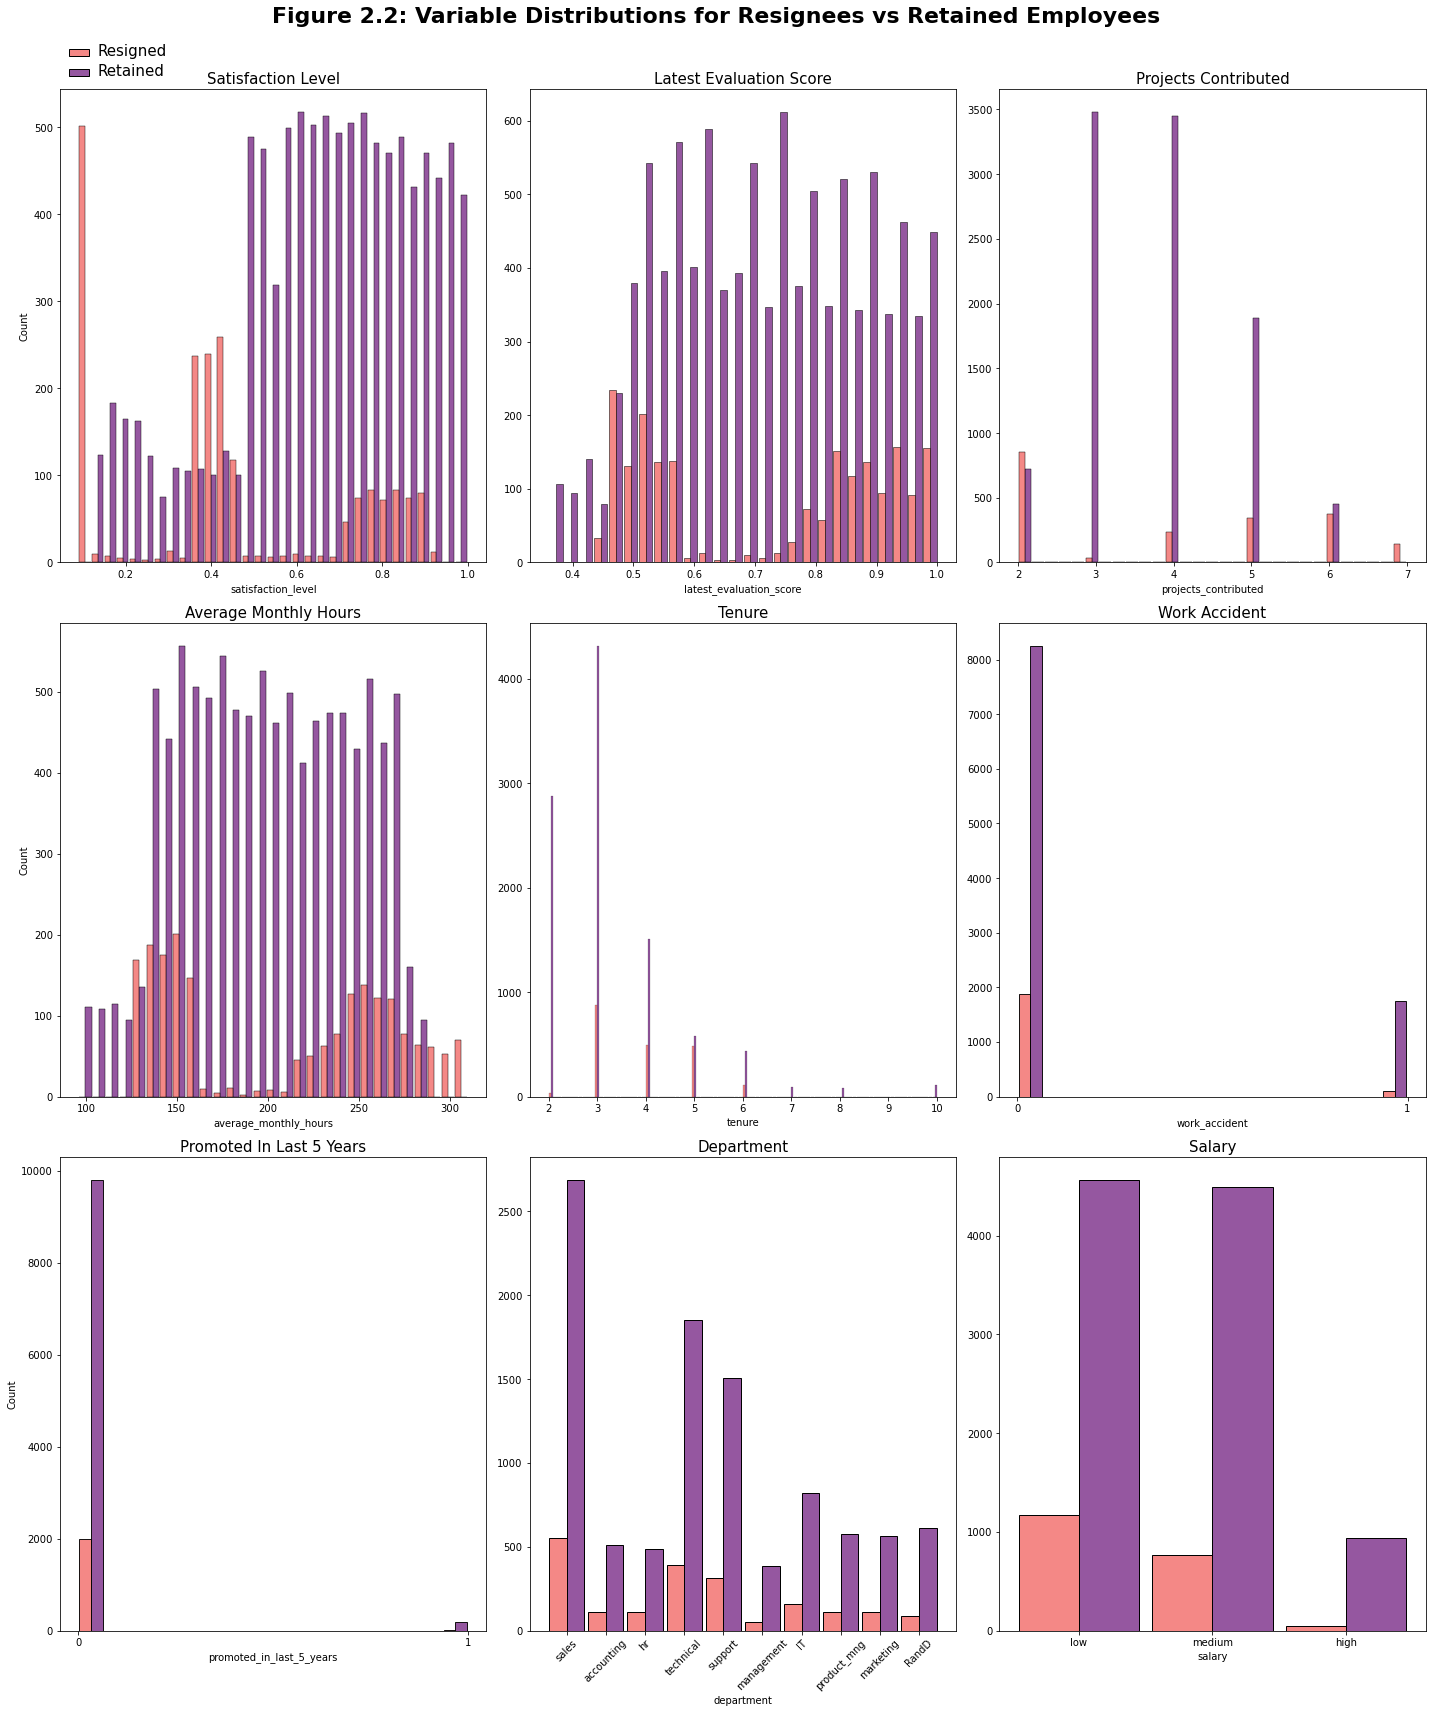

In [329]:
fig, axes = plt.subplots(3,3,figsize=(20,25))

# Flatten the 2D array to 1D for easy iteration
axes = axes.flatten()

new_labels = {0: "Retained", 1: "Resigned"}

a= 0
for i in df.columns.drop("left"):
    sns.histplot(x=df[str(i)], ax= axes[a], multiple='dodge',hue=df["left"].replace(new_labels),legend=(a == 0), shrink=0.9, palette="magma_r")
    axes[a].set_ylabel("")
    axes[a].set_title(i.replace("_"," ").title(), fontsize=15)
    a += 1
    
for i in range(0,9,3):
    axes[i].set_ylabel("Count")

axes[5].set_xticks([0, 1])
axes[6].set_xticks([0, 1])

sns.move_legend(axes[0], "upper left", bbox_to_anchor=(0, 1.115)) # Moves it outside
axes[0].get_legend().set_title("")
axes[0].get_legend().get_frame().set_linewidth(0.0) # Removes the box around the legend
for text in axes[0].get_legend().get_texts():
    text.set_fontsize(15)


for tick in axes[7].get_xticklabels():
    tick.set_rotation(45)


fig.suptitle("Figure 2.2: Variable Distributions for Resignees vs Retained Employees", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


The histograms above compare the feature distributions for employees who resigned (orange) against those who were retained (purple). The visualizations reveal several clear diverging patterns between the two cohorts:

1. The **Workload & Satisfaction** Paradox
    * We observe that employees who left the company generally reported lower satisfaction levels and higher average monthly hours compared to those who remained. However, the first four features (satisfaction_level, last_evaluation, number_project, and average_monthly_hours) exhibit multi-modal distributions for the resignation group.
    
    * In contrast, the retained group follows more uniform or unimodal (single-peaked) distributions. This divergence suggests two distinct archetypes of attrition:
    
        * The _**Disengaged/Low-Performer**_: Employees with low project counts (2), low satisfaction, and lower monthly hours, likely leaving due to a lack of motivation or under-utilization.

        * The _**Overworked High-Performer**_: Employees with high evaluation scores and excessive project loads (6–7 projects) who likely resigned due to burnout or being recruited by competitors.

2. **Project Load and the "Burnout Threshold"**
    * The project count distribution provides a striking insight: while there is a peak of resignations at 2 projects (low engagement), there is a secondary surge at 6 projects. Most notably, at the 7-project level, the data shows a 100% attrition rate. This indicates a "performance ceiling" where employees are virtually guaranteed to leave due to extreme workload. Conversely, employees with a "sweet spot" evaluation score between 0.6 and 0.8 appear most likely to stay.

3. **Tenure and Survival Analysis**
    * Attrition is heavily concentrated in the mid-tenure period (years 3–5). Interestingly, by year 6, the resignation rate drops significantly, and from year 7 onwards, the probability of retention reaches 100%. This supports the burnout theory: unhappy or overworked employees generally leave before reaching the 6-year mark; those who "survive" this period are highly likely to remain with the company long-term.

4. **Workplace Safety and Career Growth**
    * **Workplace Safety**: A significant portion of those who resigned had experienced a work accident, highlighting workplace safety as a potentially critical factor in employee turnover.
    * **Promotions**: The vast majority of employees have not received a promotion in the last five years. Despite evidence of workers working longer than the industry average it is surprising to see that so few were promoted. This could be a motive behind lower satisfcation levels leading to attrition. However, among the few who were promoted, retention was significantly higher, underscoring the importance of career progression as a retention tool. 
    * **Salary**: While high-salary positions are infrequent in both groups, the lack of high-earning individuals in the resignation cohort is more stark. In other words, lower and medium salary levels correlate much more strongly with employee attrition than high-level compensation 
    * **Department**: There is no apparent impact of specific departments on employee turnover, suggesting the issues may be systemic across the entire organization. 


These insights confirm that attrition at Salifort Motors is not driven by a single factor but by a combination of workload, tenure, and lack of growth. These identified non-linear relationships and multimodal distributions will be essential in informing our feature engineering and model selection.

Next let's create some boxplots to visualize the spread of Satisfaction Level, Latest Evaluation Score, Projects Contributed, Average Monthly Hours, and compare them for retained vs resigned employees.



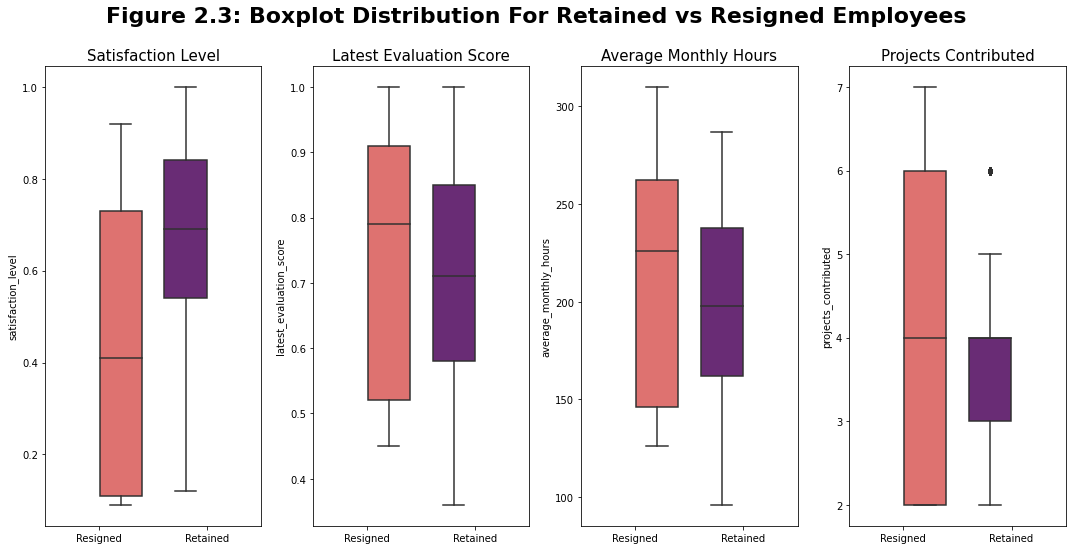

In [330]:
fig, axes = plt.subplots(1,4,figsize=(15,8))

a= 0
for i in ["satisfaction_level","latest_evaluation_score","average_monthly_hours","projects_contributed"]:
    sns.boxplot(x=df["left"].replace(new_labels),y=df[str(i)],hue=df["left"],ax= axes[a],palette="magma")
    axes[a].get_legend().remove() # Remove legend from all subplots to avoid repetition
    axes[a].set_title(i.replace("_"," ").title(), fontsize=15)
    axes[a].set_xlabel("")
    a += 1
    

fig.suptitle("Figure 2.3: Boxplot Distribution For Retained vs Resigned Employees", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

The boxplots above show that employees who resigned exhibited **lower satisfaction levels**. Interestingly, they also tended to have **higher evaluation scores, participated in more projects, and logged more average monthly working hours** than those who remained with the company.

The Interquartile Ranges (IQR) for all four variables are significantly wider for the resignation cohort than for retained employees. This increased dispersion indicates that the retained group is more homogeneous, whereas the resignee group exhibits greater variance. 


These findings align with the previously identified multi-modal distributions, further suggesting that those who leave the company comprise several distinct subgroups with diverging professional profile. These profiles can be categorized as:

_**The Overworked High Performer Leaving:**_ 

The data reveals a distinct segment of overachievers who appear to be pushed to a breaking point. This cohort is characterized by exceptional evaluation scores (0.8–1.0) and excessive workloads (230–310 hours per month). Notably, both the "performance floor" (minimum evaluation) and the "workload floor" (minimum hours) are significantly higher for those who resigned than for those who were retained.
    
The project load serves as a definitive threshold: the median project count for resignees aligns with the 75th percentile of the retained group, and assigning a seventh project results in a 100% attrition rate. When these high demands are coupled with stagnant career progression (barely any promotion) and lower salary tiers, satisfaction levels collapse into the 0.1–0.4 range. These metrics strongly suggest that the company’s most valuable contributors are leaving due to systemic burnout, performance ceilings, or aggressive poaching by competitors.

_**The Retention "Sweet Spot":**_ 

Employees who remain with the company exhibit a high degree of homogeneity across core metrics. This "retention cluster" is characterized by a sustainable equilibrium: performance evaluations between 0.60 and 0.85, a moderate workload of 160 to 230 monthly hours, and involvement in 3 to 4 projects. This balance directly correlates with healthy satisfaction levels, typically ranging from 0.55 to 0.85, suggesting that this specific workload-to-reward ratio is key to long-term employee stability.

_**The Under-utilized/Disengaged Worker Archetype:**_

Across all four key metrics, the 25th percentile (Q1) is notably lower for the resignation group than for the retained group, indicating a higher concentration of low-engagement profiles among those who leave. Specifically, a clear cluster of resignees is characterized by a "low-utilization" profile: contributing to only two projects and working fewer than 160 hours per month (below the standard 40-hour work week). This group typically reports lower motivation and satisfaction scores. These findings strongly support the bimodal attrition theory: employees tend to exit the organization at two extremes—either when they are critically overloaded (7 projects) or when they are significantly under-utilized (2 projects).


#### Variable Relationships

In this section we will move from univariate analysis (looking at one variable) to bivariate and multivariate analysis. We will explore the interrelationships between features to identify patterns that contribute to attrition. Understanding how variables correlate and interact is essential for determining the key drivers of employee departure. 

We will begin by analyzing how retention patterns shift as we examine the interaction between pairs of variables.

The code below creates a custom function to create a scatter plot between two variables

In [331]:
# Custom function to create scatterplots  with different colors for resignees vs retained employees. 
def scatterplt(x,y,a):
    '''
    Arguments:
        x (string): the column name for the x-axis
        y (string): the column name for the y-axis
        a (string or int): the subplot index or 'n/a' for a single plot

    Returns a scatterplot for the specified x and y variables, with different colors for resignees vs retained employees. 
    If a subplot index is provided, it creates the scatterplot in the corresponding subplot; otherwise, it creates a single scatterplot.
    '''

    if a == 'n/a': 
        #For a single scatterplot without subplots
        sns.scatterplot(data=df[df["left"]==0],y=y,x=x,color='purple',alpha=0.05)
        sns.scatterplot(data=df[df["left"]==1],y=y,x=x,color='orange')
        plt.suptitle("Employee Retention Patterns across "+ y.replace("_"," ").title(), fontsize=22, fontweight='bold')
    else: 
        #For multiple scatterplots in subplots
        sns.scatterplot(data=df[df["left"]==0],y=y,x=x,color='purple',alpha=0.05, ax=axes[a])
        sns.scatterplot(data=df[df["left"]==1],y=y,x=x,color='orange', ax=axes[a])
        axes[a].set_title("Variation with "+x.replace("_"," ").title(),fontsize=15)
        
    # 1. Create custom "handles" for the legend
    orange_dot = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', label='Resigned')
    purple_dot = mlines.Line2D([], [], color='purple', marker='o', linestyle='None', label='Retained', alpha=0.3)

    # 2. Add a single legend to the figure (not the axis)
    fig.legend(handles=[orange_dot, purple_dot], 
           loc='lower center', 
           ncol=2,
           frameon=False,
            bbox_to_anchor=(0.5, -0.01),
           fontsize=12)

**Impact of Work Hours and Evaluation Scores on Satisfaction Levels**


We will now examine how average monthly hours and evaluation scores impact satisfaction levels, comparing the distributions between employees who were retained and those who resigned.

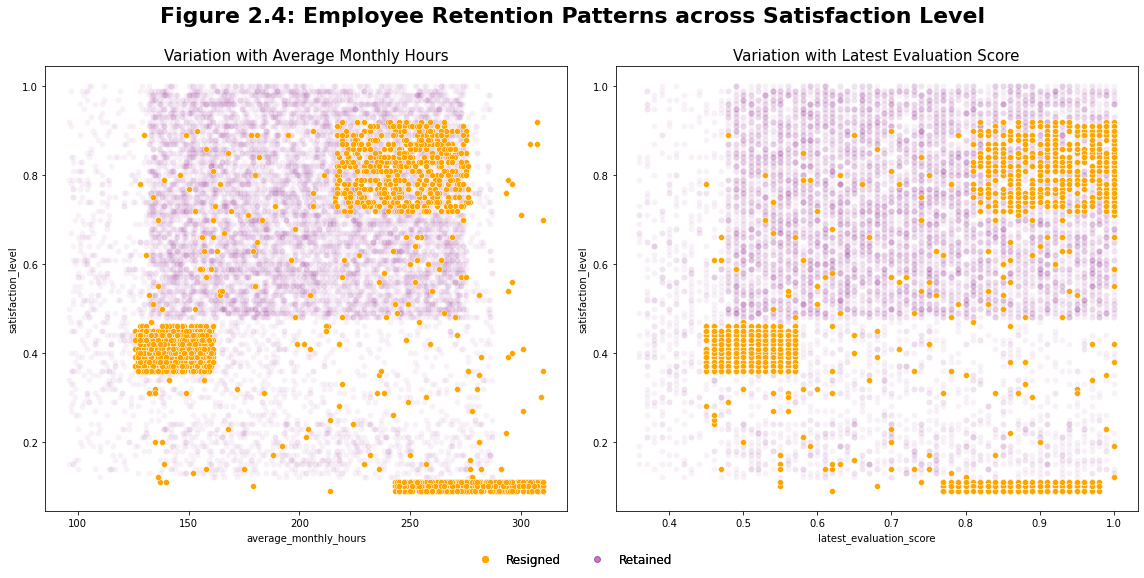

In [332]:
fig, axes = plt.subplots(1,2,figsize=(16,8))
axes = axes.flatten()

scatterplt("average_monthly_hours","satisfaction_level",0)
scatterplt("latest_evaluation_score","satisfaction_level",1)
fig.suptitle("Figure 2.4: Employee Retention Patterns across Satisfaction Level",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

The left two visualizations reveal three distinct clusters of employees who left the organization:

1. _**The "Workhorses" (Top Right)Profile:**_ 

    _High Satisfaction ($> 0.7$), High Evaluation ($> 0.8$), and High Monthly Hours ($220$–$275+$)._

    These are our top performers. They are satisfied and highly rated but are likely being overworked. They may be leaving for better opportunities or because they have hit a ceiling, despite being "happy."

2. _**The "Strugglers" (Middle Left)Profile:**_ 

    _Moderate Satisfaction ($0.35$–$0.45$), Low/Mid Evaluation ($\approx 0.45$–$0.55$), and Lower Hours ($\approx 130$–$160$)._
    
    These employees seem to be in a "danger zone." They aren't performing well, aren't very satisfied, and aren't working many hours. This cluster likely represents people who were either a bad fit for their roles or were already mentally checked out before leaving.

3. _**The "Burnt Out" (Bottom Right)Profile:**_ 

    _Very Low Satisfaction ($< 0.2$), High Evaluation ($> 0.8$), and Very High Hours ($250$–$300+$)._
    
    This is a classic burnout profile. These are high-performing individuals (per the last_evaluation plot) who are working extreme hours but are miserable. Their low satisfaction is a direct indicator of impending resignation due to overwork.

The data suggests that turnover isn't just about "unhappy" people. There is a significant retention issue with high achievers. The High-Hour/High-Evaluation group (Top Right and Bottom Right) represents the most "expensive" loss to the company as it is losing its most competent talent.

**Work Hours and Evaluation Scores**

Next we will examine how average monthly hours and evaluation scores correlate with each other, again comparing the distributions between employees who were retained and those who resigned.

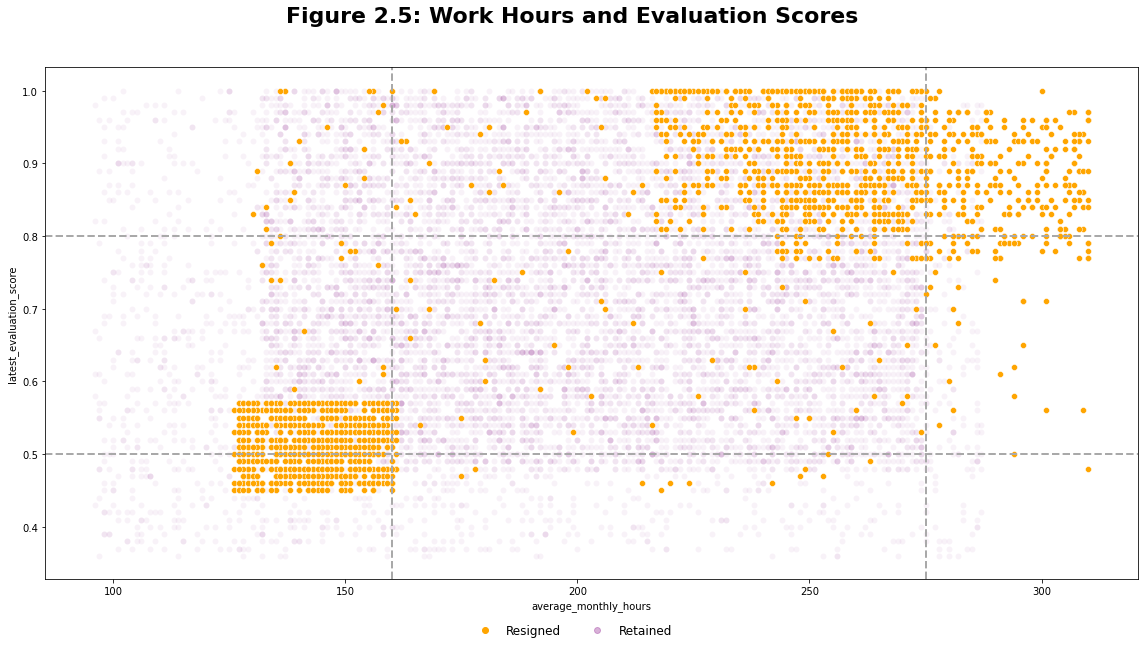

In [333]:
fig, axes = plt.subplots(figsize=(16,9))

scatterplt("average_monthly_hours","latest_evaluation_score",'n/a')
fig.suptitle("Figure 2.5: Work Hours and Evaluation Scores",fontsize=22, fontweight='bold')
plt.axhline(y=0.8, color='darkgray', linestyle='--', linewidth=2)
plt.axhline(y=0.5, color='darkgray', linestyle='--', linewidth=2)
plt.axvline(x=160, color='darkgray', linestyle='--', linewidth=2)
plt.axvline(x=275, color='darkgray', linestyle='--', linewidth=2)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

By comparing Work Hours against Evaluation Score, we can identify three distinct "clusters" of employees who choose to resign.
The orange dots (Resigned) are not scattered randomly; they form two key profiles of turnover echoing our observations from the chart above:

1. _**The "Underworked & Underperforming" (Bottom Left):**_

_Roughly 130–160 hours/month with evaluation scores between 0.45 and 0.57_

These employees are likely "checked out." They aren't working many hours and aren't performing well. Their resignation might be a case of "quitting before being fired" or a total lack of engagement with the role.

2. _**The "High-Performing Burnouts" (Top Right):**_

_Stats: Over 220 hours/month with evaluation scores between 0.80 and 1.0._

This is the most **concerning** cluster for the company. These are the "star players" who are highly evaluated but are working extreme hours (well over the standard 160–170 hour work month). They are likely leaving due to burnout or finding better work-life balance elsewhere.



**Visual Observations:** 

* The purple dots are generally spread out whereas the orange dots tend to be clustered
    * Higher working hours do not guarantee a higher evaluation but do tend to lead to reignation

* The 160-220 hours with 0.6-0.8 scores area is mostly concentrated with purple dots rather than orange ones. 
    * This suggests that "moderate" work hours and "good but not perfect" scores are the "safe zone" for employee retention.

* Beyond 275 houes, we mostly see a concentration of orange dots. Therefore assigning employees more work than this is almost a guaranteed predictor of resignation

As mentioned above, the Top Right cluster should be the key focal point of any retention strategy. High performers are being pushed to work nearly double a standard work week, which is a recipe for losing your best talent. This represents the most "expensive" loss to the company

**What happens as time spent in the Company increases**


Next we will analyze how satisfaction level, latest evaluation score, average monthly hours, and projects contributed change as employees spend more time at the company. This analysis can help us identify critical periods in an employee's tenure where interventions may be most effective in improving retention.

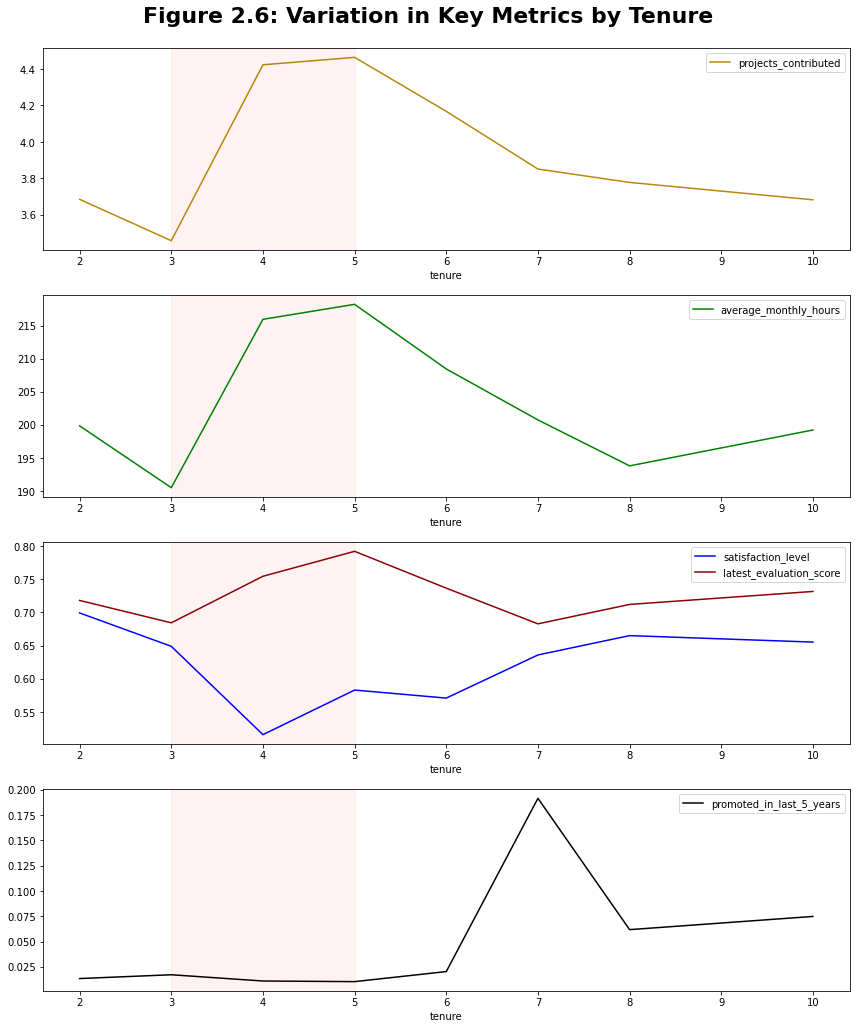

In [334]:
fig, axes = plt.subplots(4,1,figsize=(12,15))

tenure_bd= df.groupby("tenure").mean()

tenure_bd[["projects_contributed"]].plot(ax=axes[0], color='darkgoldenrod')
tenure_bd[["average_monthly_hours"]].plot(ax=axes[1], color='green')
tenure_bd[["satisfaction_level","latest_evaluation_score"]].plot(ax=axes[2],color=['blue','darkred'])
tenure_bd[["promoted_in_last_5_years"]].plot(ax=axes[3],color=['black'])


for ax in axes:
    ax.axvspan(3, 5, color='red', alpha=0.05, label='Critical Retention Period')

fig.suptitle("Figure 2.6: Variation in Key Metrics by Tenure", fontsize=22,fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

The linecharts above essentially uncovers a "High-Performer Flight Risk" in this company. We see that Tenure reaches a critical point in Years 3-5. By year 3, they have gained experience and skills, and are rewarded with more work and responsibility (4-5 projects and 215+ monthly hours). The employee reaches their peak value to the company as reflected by the incessant increase in the highest evaluation score upto the maxmium value of 0.8 in year 5. However, exactly as the workload peaks, satisfaction levels hit its absolute floor at year 4. We also see that there is no promotion during this time period. The outcome is that employees leave at the peak of their value to the company. These line charts thus provide the "smoking gun" that confirms our burnout theory.

Notably, while projects, hours, and evaluations are skyrocketing, the promotion rate is flat and near zero until Year 7. However, as shown in Figure 2.2, employees with a propensity to leave do not remain with the company beyond Year 6. This indicates that by the time the promotion window opens, the organization has already lost the cohort most likely to resign. The data confirms a classic "too little, too late" management failure.

The current incentive structure at Salifort Motors is fundamentally misaligned, inadvertently penalizing top performers. By adhering to a "tenure-gated" promotion model (Year 7) rather than a "merit-based" framework (Year 4), the organization effectively rewards high performance (Evaluation > 0.75) with increased workload instead of career advancement. To stabilize the workforce, management must intervene by Year 3, decoupling high performance from infinite workload scaling. Transitioning to a model where high evaluations trigger promotions or salary adjustments—rather than additional projects—is essential to retaining high-value talent.

**Employee Retention Patterns across Tenure**

Next we will examine how the retention patterns vary with tenure, looking at satisfaction levels, average monthly hours and evaluation scores, again comparing the distributions between employees who were retained and those who resigned.


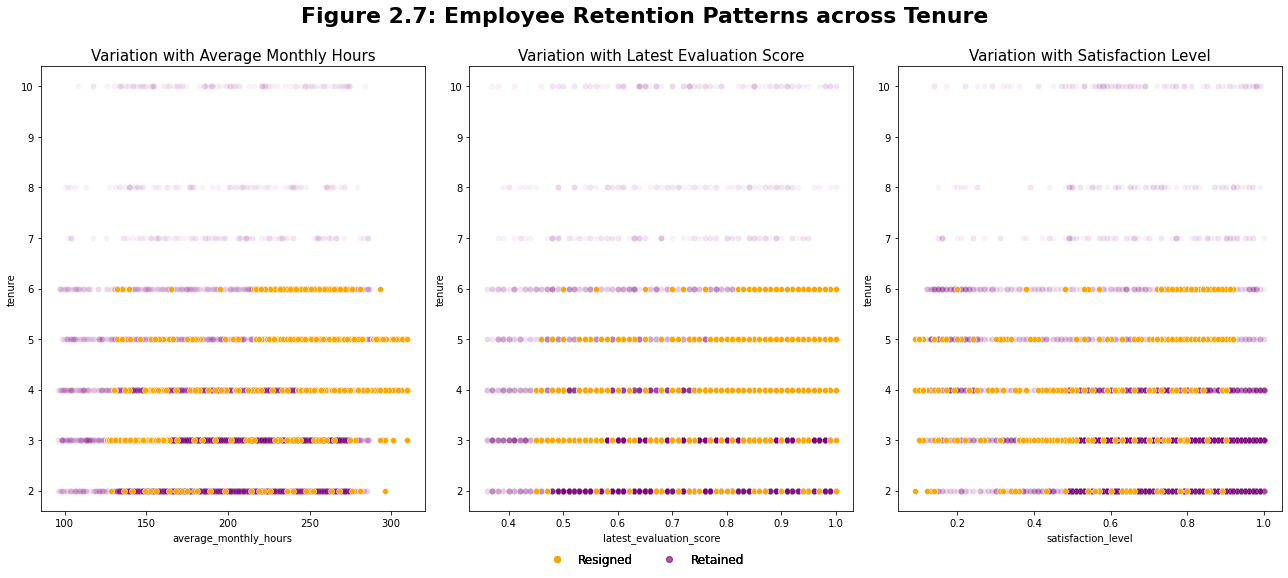

In [335]:
fig, axes = plt.subplots(1,3,figsize=(18,8))

axes = axes.flatten()

scatterplt("average_monthly_hours","tenure",0)
scatterplt("latest_evaluation_score","tenure",1)
scatterplt("satisfaction_level","tenure",2)

fig.suptitle("Figure 2.7: Employee Retention Patterns across Tenure",fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

The visualizations confirm a critical retention window between **Years 3 and 5**. This period represents a "inflection point" where employee behavior diverges significantly from the relative stability observed in early-tenure (2 years) and long-tenure (7+ years) staff.

**Key Observations:**

*   **The Loyalty Threshold:** Attrition is almost non-existent for employees with 7 or more years of tenure. Once an employee reaches this "Loyalty Threshold," they remain with Salifort Motors regardless of workload or satisfaction levels.
*   **The Overworked High-Performer (Burnout Cluster):** Between years 3 and 5, there is a dense concentration of resignations among employees with high evaluation scores and excessive workloads (200+ monthly hours). This validates the hypothesis that top talent is being pushed to a breaking point and departing at the height of their value to the company.
*   **The Under-utilized Employee:** Conversely, a distinct cluster of resignees in the same tenure bracket (Years 3–5) exhibits low engagement—characterized by fewer than 160 hours and evaluation scores below 0.6. This supports the theory that lack of challenge and under-utilization are equally potent drivers of turnover.
*   **The Dissatisfaction Peak:** Satisfaction levels show a marked decline during the 3–5 year window for those who leave, identifying this period as the primary timeframe for morale-related departures.
*   **Strategic Exiters:** Interestingly, a small cluster of employees with high satisfaction scores resigns between Years 4 and 6. This likely represents high-performers who are highly marketable and are being successfully recruited by competitors.

**Summary of Patterns**

The organizational **"Danger Zone"** is the 3 to 5-year tenure window. Targeted interventions—such as workload rebalancing for high-performers and career development for under-utilized staff—are most critical during this period to prevent the loss of both current productivity and future leadership.

#### Hypothesis Testing to Compare Satisfaction Levels for Employees in the Critical Retention Period of 3-5 years vs those outside of that period.

We will now from Data visualizations to statistical analyisis to test whether the observed differences in satisfaction levels for employees in the critical retention period of 3-5 years (mid tenure employees) vs those outside of that period are statistically significant.

Particularly we will see if `mid_tenure` employees (employees with 3-5 years of tenure) are **less satisfied** with the company than compared to the rest of the employees. We will formulate our null and alternative hypotheses as we the following:

We define mid-tenure employees as employees who have spent between 3 and 5 years in the company

*   $H_0$: Mid-tenure employees have equal or higher satisfaction Levels than the rest of the employees.
*   $H_A$: Mid-tenure employees have lower satisfaction Levels than the rest of the employees.


In [336]:
# Lets create a seperate variable for those in the critical retention period of 3-5 years to compare with those outside of that period.
df['mid_tenure'] = np.where((df['tenure'] >= 3) & (df['tenure'] <= 5),1,0)

# 1. Isolate the `satisfaction_level` column for mid-tenure employees.

mid_tenure = df[(df['mid_tenure'] == 1)]['satisfaction_level']

# 2. Isolate the `satisfaction_level` column for employees outside the mid-tenure period.
not_mid_tenure = df[(df['mid_tenure'] == 0)]['satisfaction_level']

# 3. Perform a one-sided Welch's t-test
two_sample= stats.ttest_ind(a=mid_tenure, b=not_mid_tenure, equal_var=False, alternative='less')
print(f"Results of Two-sample t-test\n \nT-stat: {two_sample[0]} \nP-value: {two_sample[1]}")
    

Results of Two-sample t-test
 
T-stat: -15.631955199332078 
P-value: 1.2368179888174746e-54


A Welch's t-test confirmed that mid-tenure employees (3-5 years) have **significantly lower** satisfaction levels compared to all other tenure groups ($t = -15.63, p < 0.001$). The extremely low p-value (p < 0.001) indicates this difference is not due to random chance and thus **mid-tenure employees are substantially less satisfied** than their colleagues at other tenure levels. This result is statistically robust and represents a critical "danger zone" for employee retention.


**Mid-Tenure Employee Resignation Analysis**

Next, we calculate the total resignations and the resignation rate by tenure group. This comparison highlights the difference in turnover behavior between employees in the 3–5 year 'mid-tenure' bracket versus the rest of the organization.

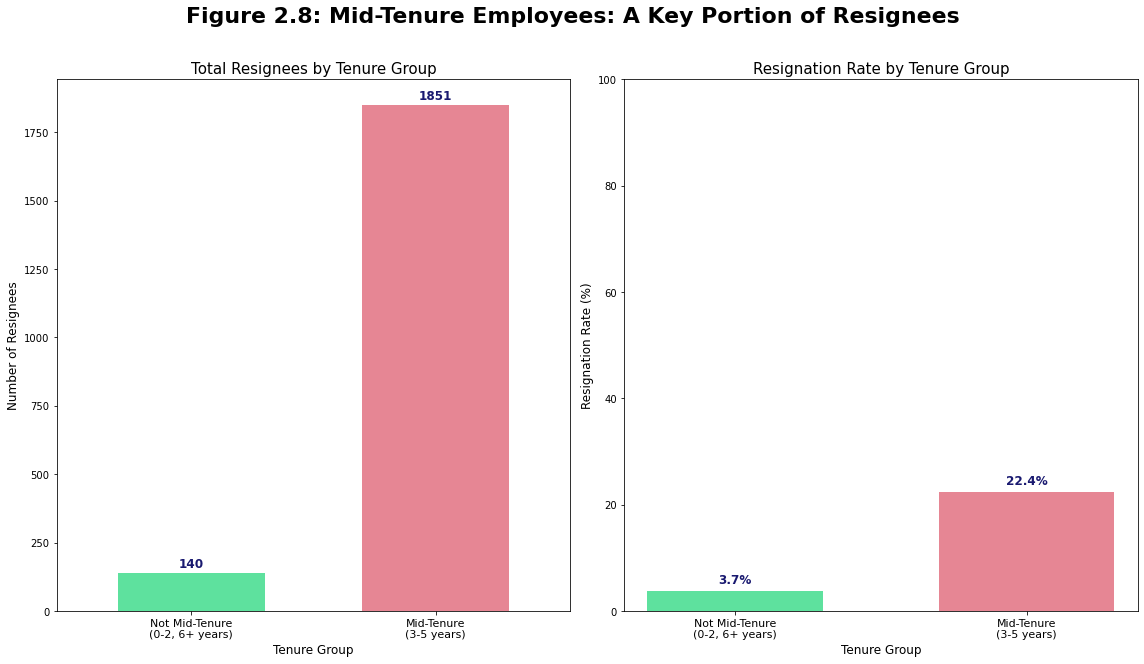

Mid-Tenure Employee Resignation Analysis
Mid-Tenure Resignees (3-5 years): 1851 out of a total of 8257 mid-tenure employees (22.4%)
Other Resignees: 140 out of a total of 3734 other employees (3.7%)

Mid-tenure employees represent 93.0% of all resignees


In [337]:
# Calculate resignation rates by mid-tenure status
mid_tenure_analysis = df.groupby('mid_tenure')['left'].agg(['sum', 'count'])
mid_tenure_analysis['resignation_rate'] = mid_tenure_analysis['sum'] / mid_tenure_analysis['count']
mid_tenure_analysis.index = ['Not Mid-Tenure (0-2, 6+ years)', 'Mid-Tenure (3-5 years)']

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Plot 1: Resignation counts
colors = ["#5EE19E", "#E68694"]
mid_tenure_analysis['sum'].plot(kind='bar', ax=axes[0], color=colors, width=0.6)
axes[0].set_title('Total Resignees by Tenure Group', fontsize=15)
axes[0].set_ylabel('Number of Resignees', fontsize=12)
axes[0].set_xlabel('Tenure Group', fontsize=12)
axes[0].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11, rotation=360,ha='center')
for i, v in enumerate(mid_tenure_analysis['sum']):
    axes[0].text(i, v + 20, str(int(v)), ha='center', fontsize=12, fontweight='bold', color='midnightblue')

# Plot 2: Resignation rate (%)
resignation_pct = (mid_tenure_analysis['resignation_rate'] * 100)
bars = axes[1].bar(range(len(resignation_pct)), resignation_pct, color=colors, width=0.6)
axes[1].set_title('Resignation Rate by Tenure Group', fontsize=15)
axes[1].set_ylabel('Resignation Rate (%)', fontsize=12)
axes[1].set_xlabel('Tenure Group', fontsize=12)
axes[1].set_xticks(range(len(resignation_pct)))
axes[1].set_xticklabels(['Not Mid-Tenure\n(0-2, 6+ years)', 'Mid-Tenure\n(3-5 years)'], fontsize=11)
axes[1].set_ylim(0, 100)
for i, (bar, v) in enumerate(zip(bars, resignation_pct)):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12, color='midnightblue')

fig.suptitle('Figure 2.8: Mid-Tenure Employees: A Key Portion of Resignees', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Mid-Tenure Employee Resignation Analysis")
print("=" * 60)
print(f"Mid-Tenure Resignees (3-5 years): {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'])} out of a total of {int(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'count'])} mid-tenure employees ({resignation_pct.iloc[1]:.1f}%)")
print(f"Other Resignees: {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'sum'])} out of a total of {int(mid_tenure_analysis.loc['Not Mid-Tenure (0-2, 6+ years)', 'count'])} other employees ({resignation_pct.iloc[0]:.1f}%)")
print(f"\nMid-tenure employees represent {(mid_tenure_analysis.loc['Mid-Tenure (3-5 years)', 'sum'] / mid_tenure_analysis['sum'].sum() * 100):.1f}% of all resignees")

From the analysis above, we can see that mid-tenure employees (those with 3-5 years of tenure) have a significantly higher resignation rate compared to other employees. 
They represent a substantial portion of all resignees, indicating that this group is particularly vulnerable to attrition. This insight suggests that targeted retention strategies for mid-tenure employees could be crucial in reducing overall attrition rates at Salifort Motors.

### Insights


Here is a summary of the primary insights derived from the visualizations created above:

The dataset shows that 83.4% of employees stayed while **16.6%** left. Employees who resigned exhibited lower satisfaction levels. They also tended to have higher evaluation scores, participated in more projects, and logged more average monthly working hours than those who remained with the company.

Attrition at Salifort Motors is not driven by a single factor but by a combination of workload, tenure, and lack of growth. By looking at the distributions and relationships for and between these, we can identify specific "risk profiles" for attrition.

**The Two Profiles of Attrition**

The data reveals that employees who leave generally fall into two distinct categories:

* The _**Overworked High-Achiever**_: These employees have high evaluation scores, work excessive hours (often exceeding 250–300 hours/month), and handle 6 or 7 projects. Every single employee in the dataset with 7 projects left the company. This is a massive red flag for workload management.
Their attrition is likely due to burnout and is indicative of a significant High Perfomer Flight Risk.

* The _**Disengaged and Under-utilized Under-performer**_: These employees work significantly fewer hours (around 150/month), have low satisfaction levels, and only handle 2 projects. Their attrition is likely due to lack of engagement or being managed out. Employees with only 2 projects have a surprisingly high exit rate (potentially feeling undervalued or underutilized).

**The Retention "Sweet Spot"**

Employees who remain with the company exhibit a high degree of homogeneity across core metrics. This "retention cluster" is characterized by a sustainable equilibrium: performance evaluations between 0.60 and 0.85, a moderate workload of 160 to 230 monthly hours, and involvement in 3 to 4 projects. This balance directly correlates with healthy satisfaction levels, typically ranging from 0.55 to 0.85, suggesting that this specific workload-to-reward ratio is key to long-term employee stability. 

**The Mid Tenure "Danger Zone"**

* The organizational **"Danger Zone"** is the 3 to 5-year tenure window.
* Attrition peaks sharply between 3 and 5 years
* If an employee stays past the 6-year mark, the likelihood of them leaving drops significantly. This suggests that retention efforts should be hyper-focused on mid-tenure employees.
* While projects, hours, and evaluations skyrocket, during the mid-tenure (3-5 years) critical period , the promotion rate is flat and near zero until Year 7. It is crucial to note that employees with a propensity to leave do not remain with the company beyond Year 6. This indicates that by the time the promotion window opens, the organization has already lost the cohort most likely to resign. The is a classic "too little, too late" management failure.
* Targeted interventions—such as workload rebalancing for high-performers and career development for under-utilized staff—are most critical during this period to prevent the loss of both current productivity and future leadership.
* Mid-tenure employees (3-5 years) have significantly lower satisfaction levels compared to all other tenure groups This result is statistically robust
* Mid-tenure employees represent 93.0% of all resignees and the resignation rate within this group is 22.4%

**Satisfaction vs. Evaluation**

* The data suggests that turnover isn't just about "unhappy" people. There is a significant retention issue with high achievers. The High- working hour/High-Evaluation group amongst the resignees represents the most "expensive" loss to the company as it is losing its most competent talent.

**Absence of Career Growth**
* The current incentive structure at Salifort Motors is fundamentally misaligned, inadvertently penalizing top performers. By adhering to a "tenure-gated" promotion model (Year 7) rather than a "merit-based" framework (Year 4), the organization effectively rewards high performance (Evaluation > 0.75) with increased workload instead of career advancement. To stabilize the workforce, management must intervene by Year 3, decoupling high performance from infinite workload scaling. Transitioning to a model where high evaluations trigger promotions or salary adjustments—rather than additional projects—is essential to retaining high-value talent.



## Section 3: Model Building and Evaluation

In this section, we transition from exploratory data analysis to predictive modeling. This phase involves preparing the dataset for machine learning through categorical encoding and feature selection, using the F1 score as the primary metric for performance evaluation. This is a supervised learning classification task because we will predict on a binary class (Whether or not each employee left or stayed). Therefore, this notebook will prepare the data for classification models.

This section is organized into two parts:

**Part A: Baseline Modeling with Logistic Regression**
We establish a baseline using a Logistic Regression model to predict employee attrition. This process includes verifying model assumptions, performing a train-test split to ensure generalizability, and evaluating results using a confusion matrix alongside standard classification metrics (precision, recall, and F1-score). This provides a statistical foundation for identifying the primary drivers of turnover at Salifort Motors.

**Part B: Advanced Modeling with Random Forest and XGBoost**
To improve predictive power, we develop and compare Random Forest and XGBoost models, and select the top performer as our champion. We utilize a train-test-validation split strategy to enhance reproducibility. For both models, we employ `GridSearchCV` on the training data to optimize hyperparameters. The "champion" model is selected based on the highest F1 score on the validation set and is then evaluated against the hold-out test data. Finally, we visualize model insights through feature importance plots—including a directional analysis for the Logistic Regression model—and visualize a decision tree from the Random Forest model.

### Data Preparation

Because Logistic Regression and most machine learning models require numerical input, we must preprocess our categorical features. We will perform label encoding on the `salary` column and generate dummy variables (one-hot encoding) for the `department` column to prepare the dataset for modeling. We also drop the orginial `tenure` variable as we have a new variable for the critical retention period of 3-5 years

In [338]:
#Create a copy of the dataframe for modeling purposes
df_model = df.copy()
# Label encode the `salary` column as an ordinal numeric category
df_model['salary'] = df['salary'].astype('category').cat.set_categories(['low', 'medium', 'high']).cat.codes
# Dummy encode the `department` column
df_model = pd.get_dummies(df_model, drop_first=False)
# As we have created a new variable for the critical retention period of 3-5 years, we can drop the original tenure variable to avoid multicollinearity
df_model.drop(columns="tenure", inplace=True) 

### Part A: Logistic Regression

This parts build the Logistic Regression model as discussed earlier. 

**Logistic Regression model assumptions** 

We will first check if our data meets the Logistic Regression model assumptions.
5 of these will be checked for now. i.e. before contructing the model and the last of these will be checked post construction.

**Pre Construction (Assumptions 1-5)**

* The outcome variable is categorical as we predict on wether an employee resigned or not
* As each observation refers to an independent employee, therefore we can assume that they are independent of each other
* Since we have dropped the tenure variable, therefore we no longer have extreme outliers in our dataset
* Given that $n \approx 15,000$, we have an adequate sample size to satisfy the assumptions required for most predictive modeling and statistical tests

Next, we will construct a correlation heatmap to identify potential multicollinearity among the predictors.

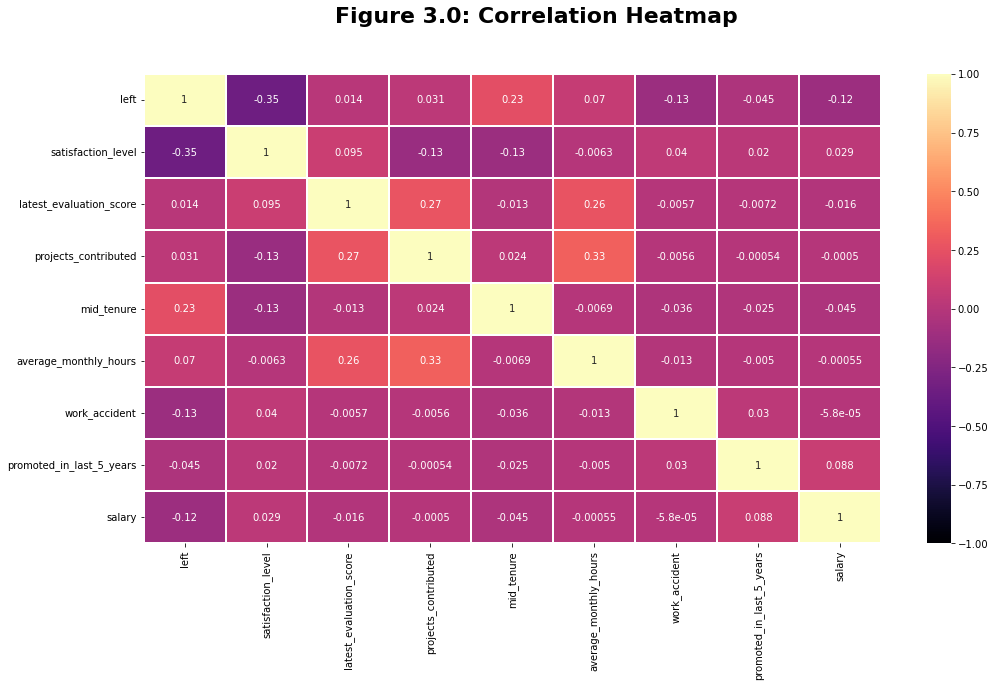

In [339]:
#### Check correlation amongst predictors

fig, axes = plt.subplots(figsize=(15,10))

sns.heatmap(df_model[['left','satisfaction_level', 'latest_evaluation_score', 'projects_contributed', 'mid_tenure', 'average_monthly_hours',
                    'work_accident', 'promoted_in_last_5_years','salary']].corr(), vmin=-1, vmax=1,
            annot=True,cmap = 'magma',linecolor='white', linewidth=0.1)
fig.suptitle('Figure 3.0: Correlation Heatmap',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

* The heatmap confirms the absence of significant multicollinearity among the independent variables, satisfying the next requirement for the logistic regression model.

We can also see that employee turnover (`left`) exhibits a negative correlation with `satisfaction_level` and a postive one with `mid_tenure`, while maintaining weak positive correlations with the rest of the variables. These muted coefficients likely stem from the non-linear nature of the data; specifically, the 'high-performer flight risk' effect is likely being masked by the exit of dissatisfied low-performers. This divergence in exit profiles confirms that a standard linear regression model may fail to capture the underlying complexities of employee attrition.


**Moddel Construction**

We first define the target variable (left) and the feature set, then partition the data into training and testing subsets, reserving 25% for evaluation. Finally, we instantiate and fit a Logistic Regression model using the training data. To account for the class imbalance in our target variable, where retained employees represent the majority class, we set the class_weight parameter to 'balanced'.

In [340]:
# Save X and y data into variables
X_log = df_model.drop(columns='left') # Only including non-continuous predictors to check for linearity assumption
y_log = df_model["left"]

#stratify = y as classes are imbalanced
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, stratify=y_log, test_size=0.25, random_state=42)

# Build regression model

clf = LogisticRegression(class_weight='balanced', max_iter=500)
clf.fit(X_train_log,y_train_log)

LogisticRegression(class_weight='balanced', max_iter=500)

 **Post Construction (Assumption 6)**

We'll now test the linearity assumption by confirming that the logit (log odds) of the outcome variable is linearly related to our continuous predictor variables

We will first use our model to calculate the predicted probabilities of resignation for each employee in the training set, and then take the log-odds (logit) of those probabilities. 
We will then check for linearity by plotting the log-odds of the target variable against each continuous predictor variable and looking for a linear pattern.

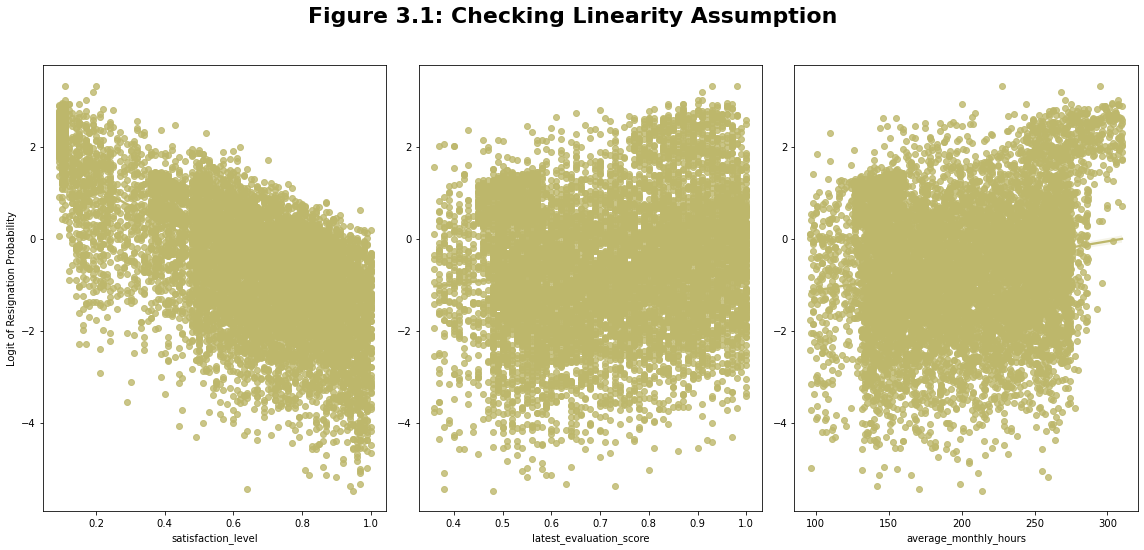

In [341]:
## Checking Linearity assumption

training_probabilities = clf.predict_proba(X_train_log)
training_probabilities

# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train_log

# 2. Create a new `logit` column in the `logit_data` df

logit_data["logit"] = [np.log(prob[1]/prob[0]) for prob in training_probabilities]

# 3. Plot the logit values against each predictor to check for linearity assumption
fig, axes = plt.subplots(1,3,figsize=(16,8))

# Flatten the 2D array to 1D for easy iteration
axes = axes.flatten()

# Only including continuous predictors to check for linearity assumption
a= 0
for i in ["satisfaction_level","latest_evaluation_score","average_monthly_hours"]:
    sns.regplot(x = str(i), y = "logit", data = logit_data, ax=axes[a], color='darkkhaki')
    axes[a].set_ylabel("") # Remove y-axis label from all subplots to avoid repetition
    a += 1

axes[0].set_ylabel("Logit of Resignation Probability")
fig.suptitle('Figure 3.1: Checking Linearity Assumption',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show();

* The plot above shows that the logit of the resignation probability has a linear relationship with satisfaction level. For latest evaluation score, and average monthly hours, the linearity assumption is not as clear but we can still see a general positive trend and the distribution of points does not show a clear non-linear pattern. The "cloud" of data points in all three charts aligns reasonably well with the straight regression lines and thus we can proceed with the logistic regression model using these variables in their current form.

**Top 5 predictors** 

Next, we identify the top five predictors by coefficient value to determine which variables exert the most significant positive or negative influence on employee attrition.

In [342]:
# Check model coefficients to understand directionality of relationships
coef_df = pd.DataFrame({
    'Feature': X_train_log.columns.drop("logit"),
    'Coefficient': clf.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
coef_df.reset_index(drop=True).head(5)

,Feature,Coefficient
0,satisfaction_level,-3.724218
1,latest_evaluation_score,1.891151
2,mid_tenure,1.619773
3,work_accident,-1.279918
4,promoted_in_last_5_years,-0.670675


The code above shows that satisfaction level, evealuation score and being in the mid-tenure employee group have the highest coefficients in the model meeting our expectations based on the EDA and our high performer flight risk theory., 
As expected, the negative coefficients for `satisfaction_level` indicates that lower satisfaction is associated with higher log-odds of resignation, 
Additionally, the positive coefficient for `latest_evaluation_score` indicates that higher evaluation scores are also associated with _higher_ (not lower) log-odds of resignation. This is in line with our high perfomer flight risk theory as it suggests that employees with higher evaluation scores are more likely to resign either due to burnout from being overworked or becaquse they find better opportunities elsewhere due to their strong performance. 
This could also be because they feel more confident in their ability to find a new job.

The positive coeffiecient for `mid_tenure` also indicates that being in the mid-tenure group is associated with higher log-odds of resignation compared to those outside of that group, which is in line with our EDA findings and our theory about the critical retention period of 3-5 years.

Lesser work accidents and being promoted in the last 5 years are also associated with higher log-odds of resignation, again confirming our insights from EDA.

It is interesting to note that the `average_monthly_hours` predictor does not have a very high coefficient in the model. This could be because its impact may already be captured by the `satisfaction_level`, `latest_evaluation_score` and `mid_tenure` predictors.

**Confusion Matrix**

We'll now construct a confusion matrix to visualize the logits regression model’s performance, providing a clear breakdown of true versus predicted outcomes.

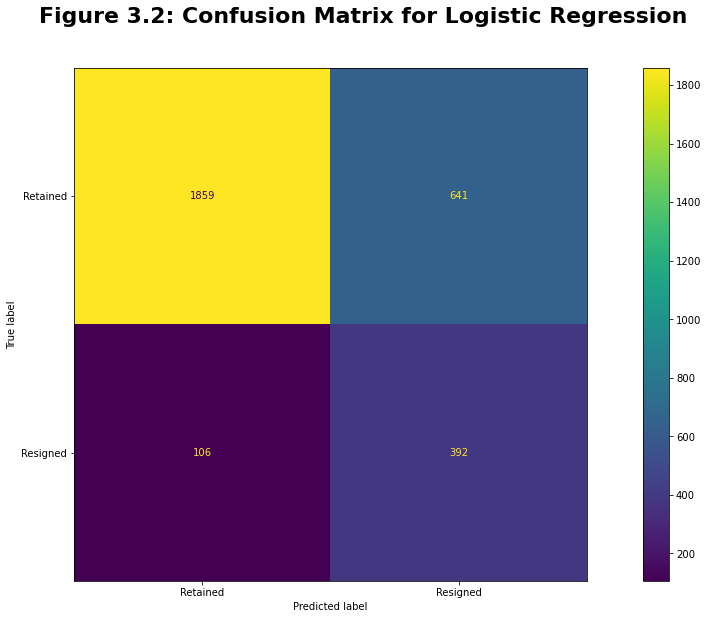

In [343]:
# Use the logistic regression model to get predictions on the test set
y_pred_log = clf.predict(X_test_log)

# Compute values and display  confusion matrix
cm = confusion_matrix(y_test_log, y_pred_log, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Retained","Resigned"])

fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Figure 3.2: Confusion Matrix for Logistic Regression", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

A confusion matrix is divided into four key categories. Since "Resigned" is our positive class (the event we are predicticting):

* **True Negatives:** The model correctly predicted 1332 employees would stay (Retained), and they did.
* **False Positives:** The model predicted 1778 employees would leave (Resigned), but they actually stayed (Retained). This is a high "false alarm" rate and is almost the same as the true negatives
* **False Negatives:** The model predicted 168 employees would stay, but they actually left (Resigned). These are "missed" resignations.
* **True Positives**: The model correctly predicted 330 employees would leave (Resigned).

Some critical observations: 
* **High False Positive Rate:** The model is very "aggressive" or "noisy." It flags almost the actually Retained employees as potential resignations (these people actually had no intention of leaving). In a business context, this could lead to wasting retention resources on the wrong people.
* **Anticipated Low Precision and Accuracy**: Due to the high volume of False Positives, we expect a significant reduction in precision. Furthermore, accuracy is estimated to be approximately 50%, suggesting the model currently lacks discriminative power, performing similarly to a random classifier

**Evaluation Results** 

We will now calculate the key classification metrics—Accuracy, Precision, Recall, and F1-score—and consolidate the results into a summary table for evaluation. These metrics can be defined as the following:

* **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
*  **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
* **F1-score** is an aggregation of precision and recall.
*  **Accuracy** measures the proportion of data points that are correctly classified.



In [344]:
# Get accuracy scores
log_precision = precision_score(y_test_log,y_pred_log)
log_accuracy = accuracy_score(y_test_log,y_pred_log)
log_recall = recall_score(y_test_log,y_pred_log)
log_f1 = f1_score(y_test_log,y_pred_log)

# Create a dataframe to store the results for the logistic regression model
results = pd.DataFrame()
results = pd.DataFrame({'model': 'Logistic_Regression',
                          'precision': log_precision,
                          'recall':log_recall,
                          'F1': log_f1,
                          'accuracy': log_accuracy}, index=range(0,1))
results

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834


The table above shows that the Logistic Regression model has an accuracy of 55%, a precision of 0.44, a recall of 0.68, and an F1 score of 0.53.

Given the above, the Logistic Regression model is currently underperforming. 
* With an accuracy so close to 50% it is not much better than random guessing. 
* While the recall score is relatively high, the low precision (and thus a lower F1 score) and results from the confusion matrix indicates that the model is generating a lot of false positives (incorrectly predicting that employees will resign when they actually stay). 
* This could lead to inefficient allocation of resources if used for decision-making, as the company might focus on retaining employees who are not actually at risk of leaving.

The low scores hence necessitate the need of a more complex algorithm to be useful for decision-making

### Part B Machine Learning Models (Random Forest and XGBoost)

For higher predictive power and better decision-making, we will now move to Machine Learing Models. We will develop and compare Random Forest and XGBoost models ultimately selecting the top performer as our champion. 
We utilize a train-test-validation split strategy to enhance reproducibility. For both models, we employ `GridSearchCV` on the training data to optimize hyperparameters. The "champion" model is selected based on the highest F1 score on the validation set and is then evaluated against the hold-out test data. 

For the subsequent models, we will exclude satisfaction_level from the feature set. Our Logistic Regression results indicate that this variable may be masking the impact of other predictors, such as average_monthly_hours. Furthermore, while satisfaction is a strong predictor, it is often a lagging indicator of workplace issues; removing it allows the model to focus on the underlying structural drivers of attrition that are more directly actionable for the organization

**Split data into test train and validation sets**

We will begin with splitting into train, validation, and test sets for the Random Forest and XGBoost models. We will reserve, 20% of the data for testing and use the remaining 80% for training and validation. We will use a 75-25 split for the training and validation sets respectively.

We will use the same X and y variables as we did for the logistic regression model with the exclusion of the `satisfaction_level' variable.

In [345]:
#X = df_model.drop(columns='left')
X = df_model.drop(columns=['left','satisfaction_level'])
y = df_model["left"]

# Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

# Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr,
                                                  test_size=0.25, random_state=42)

**Train Random Forest Model**

Next we will train the Random Forest Model using the training data. 
We will use `GridSearchCV` to tune the hyperparameters and find the best combination of parameters for our model. For this purpose we define a dictionary of hyperparameters to tune, as well as a scoring metric to evaluate the performance of the model. We will use F1 score as our scoring metric as it is a good measure of model performance for imbalanced classification problems like ours.
    
Next, we will insantiate the `GridSearchCV` object with the Random Forest model, the hyperparameters to tune, the scoring metric, and set the number of cross-validation folds to 4. 
We will then fit the `GridSearchCV` object to the training data to find the best combination of hyperparameters for our model.

For time-saving purposes we will use a pickle to save our model after fitting the `GridSearchCV`, so that we can read it back without having to run the `GridSearchCV` again. 
For this reason the code for fitting the `GridSearchCV`, as well as the code for saving and reading the model is left commented out to avoid long runtimes during testing. You can uncomment those lines when you are ready to fit the model and capture the results.



In [346]:
%%time

rf = RandomForestClassifier(random_state=42)

# Assign a dictionary of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 0.9],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }  

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'recall'}

# Instantiate GridSearch
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1')

# Fit the GridSearchCV object to the training data
# This may take a few minutes to run depending on the computational resources available

# The code is left commented out to avoid long runtimes during testing, but should be run when you are ready to fit the model and capture the results.
# Uncomment the line below to run the GridSearchCV for Random Forest model tuning. 

#rf_cv.fit(X_train, y_train) 

CPU times: user 10.8 ms, sys: 4.69 ms, total: 15.5 ms
Wall time: 2.01 ms


The code below is optional and can be used to save the model after fitting the GridSearchCV for Random Forest.

In [347]:
# Optional code to save the model after fitting the GridSearchCV for Random Forest.

# Define a path to the folder where you want to save the model 
path = Path.home() / "Downloads" / "Coursera" / "Google Advanced Data Analytics" / "Project_Salisfort_Motors_Employee_Attrition" / "hr_rf_cv_model.pickle"

# Write the model to a file using pickle 
# Note: Uncomment the lines below to save the model after fitting the GridSearchCV for Random Forest.

#with open(path, 'wb') as to_write:
#   pickle.dump(rf_cv, to_write)

# Read the model back from the file 
with open(path, 'rb') as to_read:
   rf_cv = pickle.load(to_read)

The code below prints the best F1 score and hyperparameters identified from the GridSearchCV for the Random Forest model tuning.

In [348]:
print("Best F1 Score from GridSearchCV: ", rf_cv.best_score_)
print("Best Parameters from GridSearchCV: ","\n", rf_cv.best_params_)

Best F1 Score from GridSearchCV:  0.8349338249508876
Best Parameters from GridSearchCV:  
 {'max_depth': None, 'max_features': 1.0, 'max_samples': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


The `GridSearchCV` results show that the best F1 score (approximately 0.835) was achieved with the following hyperparameters: max_depth of None, max_features of 1.0, max_samples of 0.7, min_samples_leaf of 1, min_samples_split of 2, and n_estimators of 300.

**Evaluation Results**

The code below contructs a `make_results()` function to capture the results from the Random Forest model after fitting the `GridSearchCV`.
The function accepts three arguments: the name we want to give to the model, the fitted `GridSearchCV` model, and the metric we want to use to locate the relevant precision, recall, F1 score and accuracy.

The function outputs a dataframe with the precision, recall, F1 score, and accuracy for the model with the best mean 'metric' score across all validation folds.

In [349]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

Next we will use the `make_results` function to extract the metrics, corresponding to the best F1 score, for our Random Forest GridSearchCV and add it to our results table.

In [350]:
results_rf_cv = make_results('Random Forest CV', rf_cv, 'f1')

results = pd.concat([results, results_rf_cv], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733


The hyperparameter-tuned Random Forest model demonstrates superior performance across all evaluation metrics compared to the baseline Logistic Regression. We observe significant gains in precision, accuracy, and F1-score, alongside a marginal improvement in recall.

**Train XGBoost Model**

Next, we will initiate and train an XGBoost model to see if we can improve our scores further. We will follow a similar process of hyperparameter tuning using `GridSearchCV` as we did for the Random Forest model. We will again define a dictionary of hyperparameters to tune, as well as a scoring metric to evaluate the performance of the model. We will again use F1 score as our scoring metric 


In [351]:
%%time
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [3,4,5],
             'min_child_weight': [1,2,3],
             'learning_rate': [0.1],
             'n_estimators': [300]
             }

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='f1')

# 5. Fit the GridSearchCV object to the training data
xgb_cv.fit(X_train, y_train)

CPU times: user 44.1 s, sys: 10.9 s, total: 55 s
Wall time: 8.19 s


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None

The code below prints the best F1 score and hyperparameters identified from the GridSearchCV for the XGBoost model tuning.

In [352]:
# Examine best score and parameters from the CV
print("Best F1 Score from GridSearchCV: ", xgb_cv.best_score_)
print("Best Parameters from GridSearchCV: ","\n", xgb_cv.best_params_)

Best F1 Score from GridSearchCV:  0.8245396649226756
Best Parameters from GridSearchCV:  
 {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300}


The results above show that the best F1 score from the `GridSearchCV` for the XGBoost model is approximately 0.824 , and the best parameters are a learning_rate of 0.1, max_depth of 5, min_child_weight of 1, and n_estimators of 300.

**Evaluation Results**

Next we will again use the `make_results` function to extract the metrics, corresponding to the best F1 score, for our XGBoost GridSearchCV and add it to our results table.

In [353]:
results_xgb_cv = make_results('XGBoost CV', xgb_cv, 'f1')
results = pd.concat([results, results_xgb_cv], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259


The optimized XGBoost model performs comparably to the tuned Random Forest, showing only a marginal decrease in scoring. 
Both models continue to show substantial performance gains compared to the initial Logistic Regression results

#### Run the best Random Forest on Validation Data

Use the get_test_scores() function to generate a table of scores from the predictions on the validation data.

In [354]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [355]:
# Use random forest model to predict on validation data
rf_val_preds = rf_cv.best_estimator_.predict(X_val)

# Get validation scores for RF model
rf_val_scores = get_test_scores('Random Forest Validation', rf_val_preds, y_val)

# Append to the results table
results = pd.concat([results, rf_val_scores], axis=0)
results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035


#### Run the best XGBoost Model on Validation Data

In [356]:
# Use XGBoost model to predict on validation data
xgb_val_preds = xgb_cv.best_estimator_.predict(X_val)

# Get validation scores for XGBoost model
xgb_val_scores = get_test_scores('XGBoost Validation', xgb_val_preds, y_val)

# Append to the results table
results = pd.concat([results, xgb_val_scores], axis=0)


results.reset_index(drop=True)

,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035
4,XGBoost Validation,0.859890,0.786432,0.821522,0.943286


#### Choose Champion Model

The best model as run on the Validation data as shown above is the XGBoost model

#### Run Champion Model on Test Data

In [357]:
#Retrain the XGB model on  Training + Validation data i.e. full data

champion = xgb_cv.best_estimator_
champion.fit(X_tr, y_tr)
#Predict on test data using final XGB
xgb_test_preds = champion.predict(X_test)
xgb_test_scores = get_test_scores('XGBoost Test (Champion)', xgb_test_preds, y_test)
results = pd.concat([results, xgb_test_scores], axis=0)

def highlight_champion(row):
    # Highlight row green if it is the champion model
    color = 'background-color: palegreen' if row['model'] == 'XGBoost Test (Champion)' else ''
    return [color] * len(row)

# 3. Apply the style (axis=1 applies it row-wise)
results.reset_index(drop=True).style.apply(highlight_champion, axis=1)


,model,precision,recall,F1,accuracy
0,Logistic_Regression,0.379477,0.787149,0.512084,0.750834
1,Random Forest CV,0.879418,0.794979,0.834934,0.947733
2,XGBoost CV,0.864334,0.788282,0.824540,0.944259
3,Random Forest Validation,0.850949,0.788945,0.818774,0.942035
4,XGBoost Validation,0.859890,0.786432,0.821522,0.943286
5,XGBoost Test (Champion),0.871314,0.816583,0.843061,0.949562


#### Champion Model Confusion Matrix

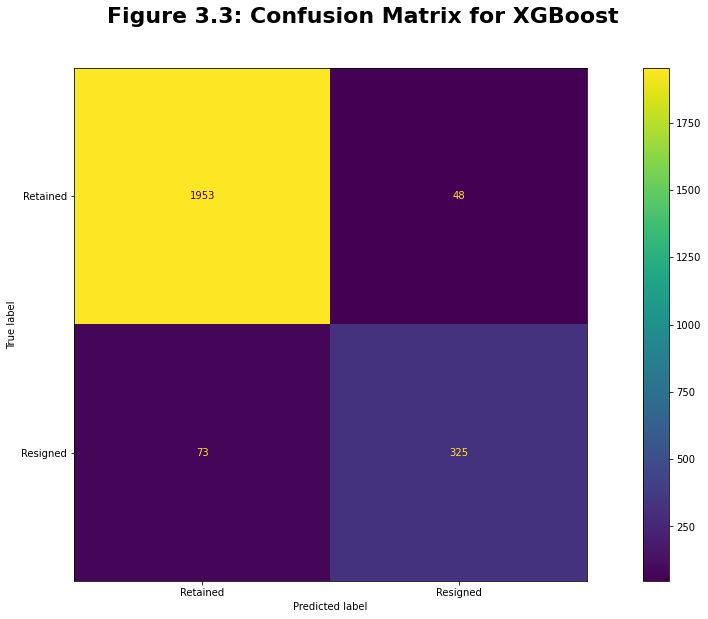

In [358]:
cm = confusion_matrix(y_test, xgb_test_preds, labels=champion.classes_)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Retained', 'Resigned'])
fig, ax = plt.subplots(figsize=(16, 9))
disp.plot(ax=ax)
fig.suptitle("Figure 3.3: Confusion Matrix for XGBoost", fontsize=22, fontweight='bold', x=0.6, horizontalalignment='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The model captured 325 true positives out of the total of 398 total actual positives. It failed to capture 73 actual positives (false negatives) and incorrectly labelled 48 negatives as positives (true positives). This is reflected by the overall high f1 score

Finally, we visualize model insights through feature importance plots—including a directional analysis for the Logistic Regression model—and visualize a decision tree from the Random Forest model.

#### Build Random Forest Model Tree

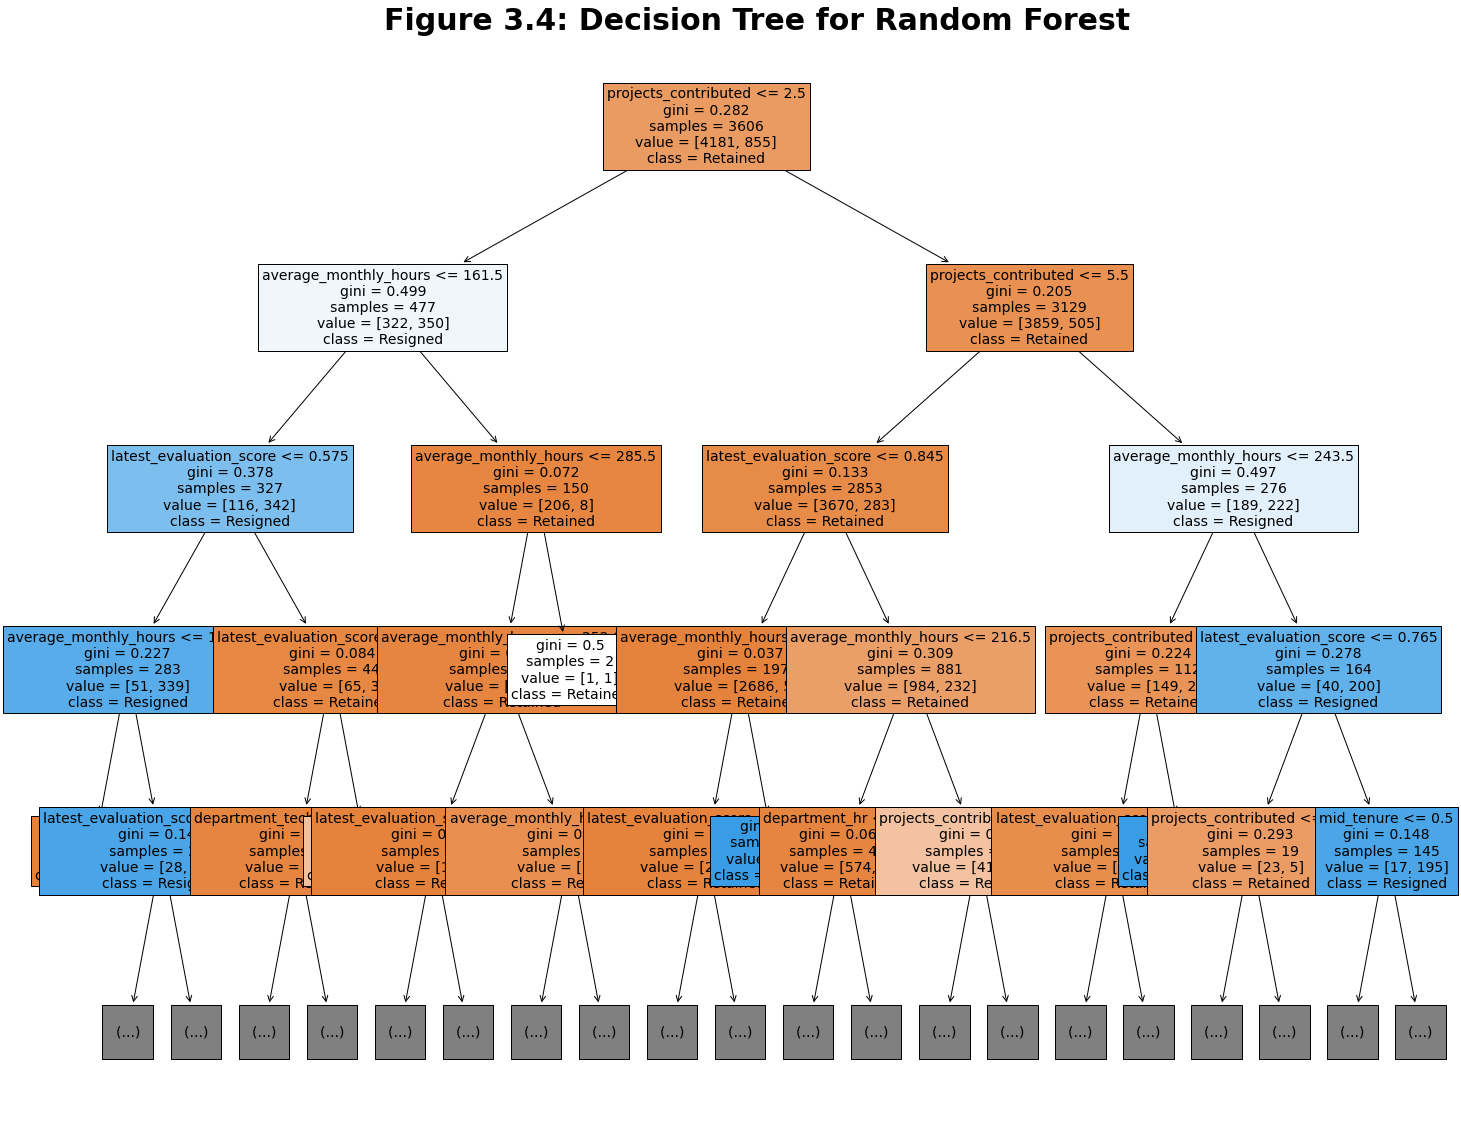

In [359]:
fig, ax = plt.subplots(figsize=(25, 20))
plot_tree(rf_cv.best_estimator_[0], max_depth=4, fontsize=14, feature_names=X.columns,class_names={0:'Retained', 1:'Resigned'}, filled=True)

ax.set_title("Figure 3.4: Decision Tree for Random Forest", fontsize=30, fontweight='bold')
plt.show()

#### Feature Importance (XGBoost Champion Model and Logistic Regression)

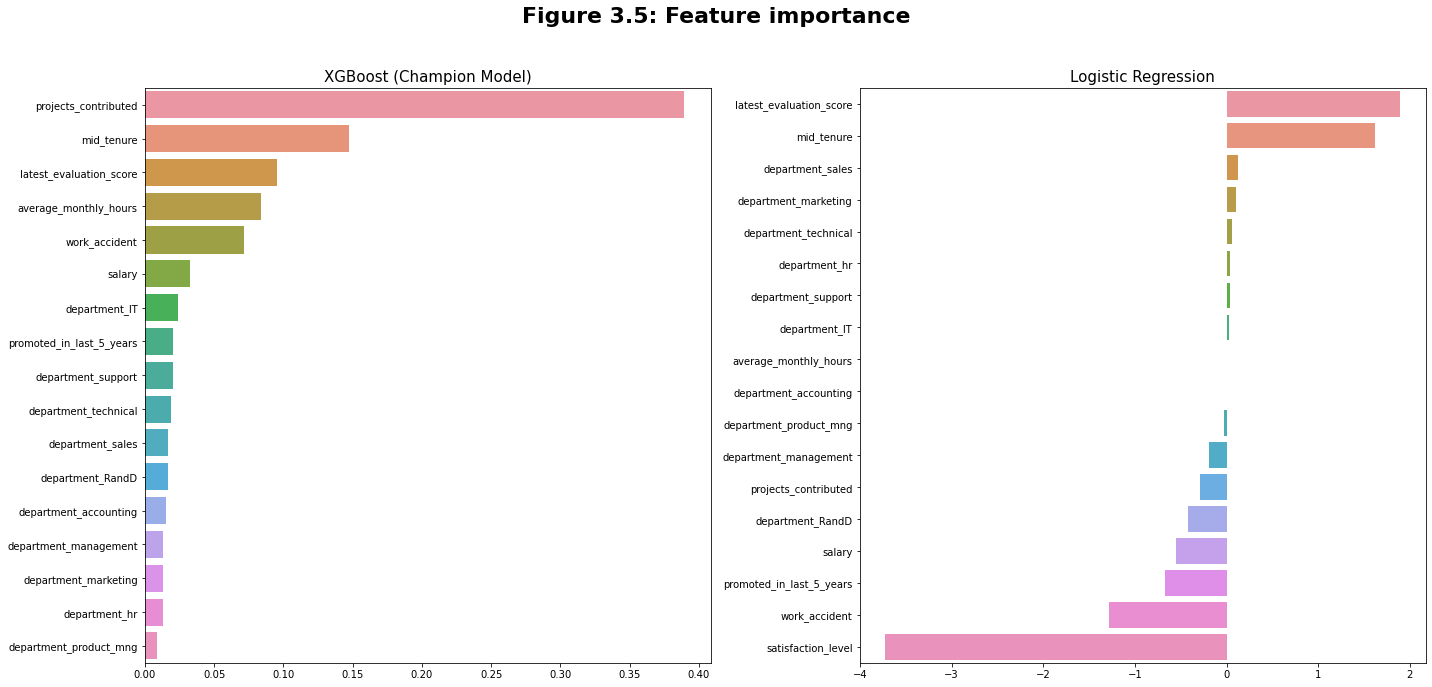

In [360]:
fig, ax = plt.subplots(1,2,figsize=(20, 10))

#Plot 1: Feature importance for XGBoost (Champion model)
importances = champion.feature_importances_
xgb_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

sns.barplot(x=xgb_importance,
            y=xgb_importance.index,
            orient='h', ax=ax[0])

ax[0].set_title('XGBoost (Champion Model)',fontsize=15)

#Plot 1: Feature importance for Logistic Regression

# Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train_log.columns, clf.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)

sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h', ax=ax[1])

ax[1].set_title('Logistic Regression',fontsize=15)

fig.suptitle('Figure 3.5: Feature importance',fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Relate with results from LogisticRegression

LR: Satisfaction level appears to have a strong negative relaionship followed bt work_accident. Mid tenure has a strong positive relationship followed by last evaluation. salary has a negative relationship but this is inline with highly paid, high performers being dissatisfied due to burnout

# Section 4: Summary and Conclusion
- Interpret model performance and results
- Share actionable steps with stakeholders



### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?

